In [90]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [91]:
df=pd.read_csv('House_Rent_Dataset.csv')
df.head()

,Posted On,BHK,Rent,Size,Floor,Area Type,Area Locality,City,Furnishing Status,Tenant Preferred,Bathroom,Point of Contact
0,2022-05-18,2,10000,1100,Ground out of 2,Super Area,Bandel,Kolkata,Unfurnished,Bachelors/Family,2,Contact Owner
1,2022-05-13,2,20000,800,1 out of 3,Super Area,"Phool Bagan, Kankurgachi",Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
2,2022-05-16,2,17000,1000,1 out of 3,Super Area,Salt Lake City Sector 2,Kolkata,Semi-Furnished,Bachelors/Family,1,Contact Owner
3,2022-07-04,2,10000,800,1 out of 2,Super Area,Dumdum Park,Kolkata,Unfurnished,Bachelors/Family,1,Contact Owner
4,2022-05-09,2,7500,850,1 out of 2,Carpet Area,South Dum Dum,Kolkata,Unfurnished,Bachelors,1,Contact Owner


In [92]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4746 entries, 0 to 4745
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Posted On          4746 non-null   object
 1   BHK                4746 non-null   int64 
 2   Rent               4746 non-null   int64 
 3   Size               4746 non-null   int64 
 4   Floor              4746 non-null   object
 5   Area Type          4746 non-null   object
 6   Area Locality      4746 non-null   object
 7   City               4746 non-null   object
 8   Furnishing Status  4746 non-null   object
 9   Tenant Preferred   4746 non-null   object
 10  Bathroom           4746 non-null   int64 
 11  Point of Contact   4746 non-null   object
dtypes: int64(4), object(8)
memory usage: 445.1+ KB


In [93]:
df.duplicated().sum()

np.int64(0)

In [94]:
df["Rent"].sort_values()[:5]

4076    1200
285     1500
471     1800
2475    2000
146     2200
Name: Rent, dtype: int64

In [95]:
df["Rent"].sort_values(ascending = False)[:5]

1837    3500000
1001    1200000
827     1000000
1329     850000
1459     700000
Name: Rent, dtype: int64

In [96]:
df['Area Type'].value_counts()

Area Type
Super Area     2446
Carpet Area    2298
Built Area        2
Name: count, dtype: int64

In [97]:
df['Furnishing Status'].value_counts()

Furnishing Status
Semi-Furnished    2251
Unfurnished       1815
Furnished          680
Name: count, dtype: int64

In [98]:
df['City'].value_counts()

City
Mumbai       972
Chennai      891
Bangalore    886
Hyderabad    868
Delhi        605
Kolkata      524
Name: count, dtype: int64

In [99]:
df['Furnishing Status'].value_counts()

Furnishing Status
Semi-Furnished    2251
Unfurnished       1815
Furnished          680
Name: count, dtype: int64

In [100]:
df['Area Locality'].value_counts()

Area Locality
Bandra West             37
Gachibowli              29
Electronic City         24
Miyapur, NH 9           22
Velachery               22
                        ..
Sangareddy District      1
Punjagutta X Roads       1
Rodamestri Nagar         1
B.S.Maktha               1
Manikonda, Hyderabad     1
Name: count, Length: 2235, dtype: int64

In [101]:
new_df=df.drop(columns=['Posted On','Area Locality','Point of Contact'], axis=1)
new_df.head()

,BHK,Rent,Size,Floor,Area Type,City,Furnishing Status,Tenant Preferred,Bathroom
0,2,10000,1100,Ground out of 2,Super Area,Kolkata,Unfurnished,Bachelors/Family,2
1,2,20000,800,1 out of 3,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1
2,2,17000,1000,1 out of 3,Super Area,Kolkata,Semi-Furnished,Bachelors/Family,1
3,2,10000,800,1 out of 2,Super Area,Kolkata,Unfurnished,Bachelors/Family,1
4,2,7500,850,1 out of 2,Carpet Area,Kolkata,Unfurnished,Bachelors,1


In [102]:
print(f"Mean Rent: {new_df.Rent.mean()}")
print(f"Median Rent: {new_df.Rent.median()}")
print(f"Highest Rent: {new_df.Rent.max()}")
print(f"Lowest Rent: {new_df.Rent.min()}")

Mean Rent: 34993.45132743363
Median Rent: 16000.0
Highest Rent: 3500000
Lowest Rent: 1200


<Axes: xlabel='Size', ylabel='Rent'>

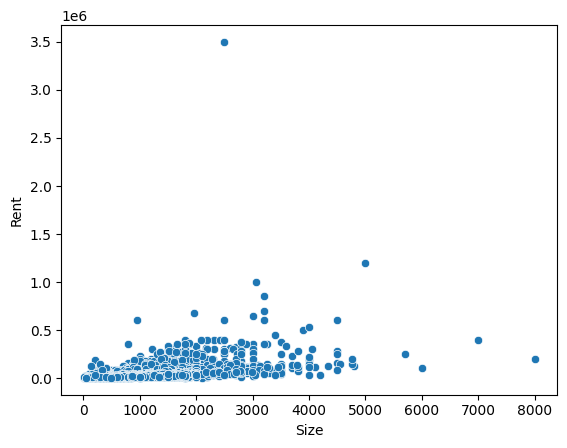

In [103]:
sns.scatterplot(data=new_df, y='Rent', x='Size')

In [104]:
new_df[['Rent','Size']].describe()

,Rent,Size
count,4.746000e+03,4746.000000
mean,3.499345e+04,967.490729
std,7.810641e+04,634.202328
min,1.200000e+03,10.000000
25%,1.000000e+04,550.000000
50%,1.600000e+04,850.000000
75%,3.300000e+04,1200.000000
max,3.500000e+06,8000.000000


In [105]:
new_df["Area Type"] = new_df["Area Type"].map({"Super Area": 1, 
                                           "Carpet Area": 2, 
                                           "Built Area": 3})
new_df["City"] = new_df["City"].map({"Mumbai": 4000, "Chennai": 6000, 
                                 "Bangalore": 5600, "Hyderabad": 5000, 
                                 "Delhi": 1100, "Kolkata": 7000})
new_df["Furnishing Status"] = new_df["Furnishing Status"].map({"Unfurnished": 0, 
                                                           "Semi-Furnished": 1, 
                                                           "Furnished": 2})
new_df["Tenant Preferred"] = new_df["Tenant Preferred"].map({"Bachelors/Family": 2, 
                                                         "Bachelors": 1, 
                                                         "Family": 3})

In [106]:
# new_df=pd.get_dummies(data=new_df)
# new_df.head()

In [107]:
X= new_df.drop(['Rent','Floor'], axis=1).values
y=new_df['Rent'].values

In [108]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=0.2, random_state=42)

In [109]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
lr=LinearRegression()
lr.fit(X_train,y_train)
y_pred= lr.predict(X_test)
print(mean_squared_error(y_test, y_pred))# features  are not normalized

2348328368.390051


In [110]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

lr_scaled = make_pipeline(StandardScaler(), LinearRegression())
lr_scaled.fit(X_train, y_train)
y_pred_scaled = lr_scaled.predict(X_test)
print(mean_squared_error(y_test, y_pred_scaled))# scaling is not a problem

2348328368.3898044


In [111]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred_scaled))
print("RMSE:", rmse)

RMSE: 48459.553943363986


In [112]:
print("y_test mean:", y_test.mean())
print("y_test std:", y_test.std())

y_test mean: 34361.85684210526
y_test std: 63129.876581323915


In [113]:
from sklearn.ensemble import RandomForestRegressor
rf=RandomForestRegressor(min_samples_split= 0.01, min_samples_leaf=0.0000012 )

rf.fit(X_train,y_train)
y_pred = rf.predict(X_test)

print('MSE',mean_squared_error(y_test, y_pred))
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print("RMSE:", rmse)
# data has non-linear patterns that Random Forest captures better

MSE 1448991885.5393713
RMSE: 38065.626036351634


In [114]:
from sklearn.model_selection import RandomizedSearchCV
param_dist = {
    "n_estimators": [200, 500, 1000],  
    "max_depth": [None, 10, 20, 30, 50], 
    "min_samples_split": [2, 5, 10, 0.01],
    "min_samples_leaf": [1, 2, 5, 10, 0.001],
    "max_features": ["sqrt", 0.5]         # features per split
}

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,                    # how many random combinations to try
    cv=3,                         
    scoring="neg_mean_squared_error",
    random_state=42,
    n_jobs=-1                     
)

search.fit(X_train, y_train)
print("Best params:", search.best_params_)

y_pred = search.best_estimator_.predict(X_test)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
print("Test MSE:", mse)
print("Test RMSE:", rmse)

Best params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 0.5, 'max_depth': None}
Test MSE: 1433135506.7147007
Test RMSE: 37856.77623246201


In [ ]:
print("Enter House Details to Predict Rent")
a = int(input("Number of BHK: "))
b = int(input("Size of the House: "))
c = int(input("Area Type (Super Area = 1, Carpet Area = 2, Built Area = 3): "))
d = int(input("Pin Code of the City: "))
e = int(input("Furnishing Status of the House (Unfurnished = 0, Semi-Furnished = 1, Furnished = 2): "))
f = int(input("Tenant Type (Bachelors = 1, Bachelors/Family = 2, Only Family = 3): "))
g = int(input("Number of bathrooms: "))
features = np.array([[a, b, c, d, e, f, g]])
print("Predicted House Price = ", search.best_estimator_.predict(features))

Enter House Details to Predict Rent
